# Inference Evaluation (Prediction vs sPLOT Ground Truth)

Dieses Notebook vergleicht eure globale Prediction pixelweise mit den Target-TIFs in `/scratch3/plant-traits-v2/data/22km/targets/comb`.

Regeln:
- Vergleich nur auf **sPLOT-Pixeln** (`source == 2` im letzten Band).
- Für Targets wird nur das **erste Band** (`mean`) verwendet.
- Prediction-Bandzuordnung wird aus der `*.band_mapping.json` gelesen.
- Wertebereich ist normiert (typisch -5 bis 5).

In [46]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

# Paths
PRED_TIF = Path("/scratch3/plant-traits-v2/predictions/global_prediction.tif")
BAND_MAP_JSON = PRED_TIF.with_suffix(".band_mapping.json")
TARGETS_DIR = Path("/scratch3/plant-traits-v2/data/22km/targets/comb")
OUT_DIR = Path(
    "/scratch3/plant-traits-v2/ldominiak/plant-traits-earth-v2/notebooks/inference_outputs"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_CSV = OUT_DIR / "trait_metrics_splot_pixels.csv"

SPLOT_MASK_VALUE = 2
MIN_VALID_PIXELS = 500
VALUE_MIN, VALUE_MAX = -5.0, 5.0

target_candidates = sorted(TARGETS_DIR.glob("X*.tif"))
if len(target_candidates) == 0:
    raise FileNotFoundError(f"No target tif files found in: {TARGETS_DIR}")
SOURCE_TIF = target_candidates[0]

print("Prediction:", PRED_TIF)
print("Band map:", BAND_MAP_JSON)
print("Targets:", TARGETS_DIR)
print("Source reference tif:", SOURCE_TIF)
print("Output dir:", OUT_DIR)

if not PRED_TIF.exists():
    raise FileNotFoundError(f"Prediction tif not found: {PRED_TIF}")
if not BAND_MAP_JSON.exists():
    raise FileNotFoundError(f"Band mapping json not found: {BAND_MAP_JSON}")
if not TARGETS_DIR.exists():
    raise FileNotFoundError(f"Target directory not found: {TARGETS_DIR}")

Prediction: /scratch3/plant-traits-v2/predictions/global_prediction.tif
Band map: /scratch3/plant-traits-v2/predictions/global_prediction.band_mapping.json
Targets: /scratch3/plant-traits-v2/data/22km/targets/comb
Source reference tif: /scratch3/plant-traits-v2/data/22km/targets/comb/X1080.tif
Output dir: /scratch3/plant-traits-v2/ldominiak/plant-traits-earth-v2/notebooks/inference_outputs


In [47]:
def parse_trait_id_from_filename(path: Path) -> int | None:
    m = re.match(r"^X(\d+)\.tif$", path.name)
    return int(m.group(1)) if m else None


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    # Use float64 for numerically stable aggregate metrics.
    yt = y_true.astype(np.float64, copy=False)
    yp = y_pred.astype(np.float64, copy=False)

    err = yp - yt
    mse = float(np.mean(err**2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(err)))
    bias = float(np.mean(err))

    denom = float(np.sum((yt - np.mean(yt)) ** 2))
    if denom <= 0.0:
        r2 = float("nan")
    else:
        r2 = float(1.0 - np.sum((yt - yp) ** 2) / denom)

    if yt.size < 2:
        corr = float("nan")
    else:
        corr = float(np.corrcoef(yt, yp)[0, 1])

    return {
        "n": int(yt.size),
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "r2": r2,
        "pearson_r": corr,
    }


with BAND_MAP_JSON.open("r", encoding="utf-8") as f:
    band_map = json.load(f)

records = band_map.get("records", [])
mean_records = [r for r in records if str(r.get("statistic", "")).lower() == "mean"]
print("Total mapping records:", len(records))
print("Mean records:", len(mean_records))

if len(mean_records) == 0:
    raise ValueError("No mean records found in band mapping JSON.")

target_files = sorted(TARGETS_DIR.glob("X*.tif"))
target_by_id = {}
for p in target_files:
    tid = parse_trait_id_from_filename(p)
    if tid is not None:
        target_by_id[tid] = p

print("Target tif count:", len(target_by_id))

# Build trait matching table between prediction mean bands and target files
rows = []
for rec in mean_records:
    band_idx_1based = int(rec["band_index"])
    trait_id = rec.get("trait_id", None)
    trait_label = str(rec.get("trait_label", "unknown"))

    target_path = None
    if trait_id is not None and int(trait_id) in target_by_id:
        target_path = target_by_id[int(trait_id)]

    rows.append(
        {
            "band_index": band_idx_1based,
            "trait_id": int(trait_id) if trait_id is not None else None,
            "trait_label": trait_label,
            "target_path": str(target_path) if target_path else None,
        }
    )

match_df = pd.DataFrame(rows)
match_df["has_target"] = match_df["target_path"].notna()

missing = match_df.loc[
    ~match_df["has_target"], ["band_index", "trait_label", "trait_id"]
]
if not missing.empty:
    display(missing)
    raise ValueError(
        f"Trait matching incomplete: {len(missing)} prediction bands have no target tif."
    )

display(match_df.head(10))
print(
    "Mean bands with matched targets:",
    int(match_df["has_target"].sum()),
    "/",
    len(match_df),
)

Total mapping records: 37
Mean records: 37
Target tif count: 37


,band_index,trait_id,trait_label,target_path,has_target
0,1,1080,X1080,/scratch3/plant-traits-v2/data/22km/targets/co...,True
1,2,13,X13,/scratch3/plant-traits-v2/data/22km/targets/co...,True
2,3,138,X138,/scratch3/plant-traits-v2/data/22km/targets/co...,True
3,4,14,X14,/scratch3/plant-traits-v2/data/22km/targets/co...,True
4,5,144,X144,/scratch3/plant-traits-v2/data/22km/targets/co...,True
5,6,145,X145,/scratch3/plant-traits-v2/data/22km/targets/co...,True
6,7,146,X146,/scratch3/plant-traits-v2/data/22km/targets/co...,True
7,8,15,X15,/scratch3/plant-traits-v2/data/22km/targets/co...,True
8,9,163,X163,/scratch3/plant-traits-v2/data/22km/targets/co...,True
9,10,169,X169,/scratch3/plant-traits-v2/data/22km/targets/co...,True


Mean bands with matched targets: 37 / 37


In [48]:
with rasterio.open(PRED_TIF) as pred_src, rasterio.open(SOURCE_TIF) as src_src:
    # Strict geometry check: no silent pixel misalignment.
    if pred_src.width != src_src.width or pred_src.height != src_src.height:
        raise ValueError("Prediction and source rasters have different width/height.")
    if pred_src.transform != src_src.transform:
        raise ValueError(
            "Prediction and source rasters have different affine transform."
        )
    if pred_src.crs != src_src.crs:
        raise ValueError("Prediction and source rasters have different CRS.")

    source_band = src_src.read(src_src.count).astype(np.float32)

    # Robust mask for sPlot-coded pixels (source == 2) with tolerance for float encoding.
    splot_mask = np.isfinite(source_band) & np.isclose(
        source_band, SPLOT_MASK_VALUE, atol=0.25
    )

    metric_rows = []
    residual_patterns = []

    for _, row in match_df.iterrows():
        band_idx = int(row["band_index"])
        trait_label = row["trait_label"]
        target_path = Path(row["target_path"])

        if band_idx < 1 or band_idx > pred_src.count:
            raise IndexError(
                f"Band index {band_idx} out of bounds for prediction with {pred_src.count} bands."
            )

        with rasterio.open(target_path) as tgt_src:
            if pred_src.width != tgt_src.width or pred_src.height != tgt_src.height:
                raise ValueError(
                    f"Grid mismatch for trait {trait_label}: width/height differ."
                )
            if pred_src.transform != tgt_src.transform:
                raise ValueError(
                    f"Grid mismatch for trait {trait_label}: transform differs."
                )
            if pred_src.crs != tgt_src.crs:
                raise ValueError(f"Grid mismatch for trait {trait_label}: CRS differs.")

            y_true_full = tgt_src.read(1).astype(np.float32)

        y_pred_full = pred_src.read(band_idx).astype(np.float32)

        valid = splot_mask & np.isfinite(y_true_full) & np.isfinite(y_pred_full)
        n_valid = int(valid.sum())

        if n_valid < MIN_VALID_PIXELS:
            print(
                f"Skip {trait_label}: only {n_valid} valid sPlot pixels (< {MIN_VALID_PIXELS})"
            )
            continue

        y_true = y_true_full[valid]
        y_pred = y_pred_full[valid]
        residual = y_pred - y_true

        m = compute_metrics(y_true, y_pred)
        m.update(
            {
                "trait_label": trait_label,
                "trait_id": row["trait_id"],
                "band_index": band_idx,
            }
        )
        metric_rows.append(m)

        # Save residual map for this trait on sPlot pixels only.
        res_map = np.full(y_true_full.shape, np.nan, dtype=np.float32)
        res_map[valid] = residual.astype(np.float32)
        residual_patterns.append((trait_label, res_map, m["bias"], m["rmse"]))

if len(metric_rows) == 0:
    raise RuntimeError(
        "No traits with sufficient valid sPlot pixels. Metrics table is empty."
    )

metrics_df = pd.DataFrame(metric_rows).sort_values("rmse", ascending=True)
metrics_df.to_csv(METRICS_CSV, index=False)
print("Saved metrics:", METRICS_CSV)
print("Traits evaluated:", len(metrics_df))
display(metrics_df.head(10))
display(metrics_df.tail(10))

Saved metrics: /scratch3/plant-traits-v2/ldominiak/plant-traits-earth-v2/notebooks/inference_outputs/trait_metrics_splot_pixels.csv
Traits evaluated: 37


,n,rmse,mae,bias,r2,pearson_r,trait_label,trait_id,band_index
8,23910,0.387600,0.295648,-0.008719,0.448659,0.672736,X163,163,9
32,23912,0.421313,0.321979,-0.024343,0.418993,0.655808,X55,55,33
15,23966,0.425373,0.322248,-0.029318,0.237733,0.491587,X27,27,16
23,23878,0.435495,0.339859,0.023285,0.442639,0.675587,X3113,3113,24
24,23927,0.436425,0.336249,-0.012219,0.461986,0.685861,X3114,3114,25
4,23917,0.438162,0.330725,0.042231,0.303659,0.577026,X144,144,5
7,23902,0.438280,0.333222,0.037761,0.393901,0.640817,X15,15,8
14,23988,0.443307,0.342321,-0.024928,0.287082,0.538874,X26,26,15
22,23902,0.446582,0.342841,0.003190,0.449497,0.676228,X3112,3112,23
19,23787,0.460229,0.322737,0.002428,0.066179,0.257853,X297,297,20


,n,rmse,mae,bias,r2,pearson_r,trait_label,trait_id,band_index
18,23736,0.577369,0.422067,0.028370,0.153417,0.405748,X289,289,19
28,23706,0.579861,0.439389,-0.086806,0.268406,0.547675,X4,4,29
21,23996,0.586979,0.471489,-0.138676,0.445383,0.703159,X3107,3107,22
29,23921,0.591191,0.447136,-0.058790,0.430118,0.678247,X46,46,30
25,23885,0.597962,0.457735,0.097630,0.441692,0.710733,X3117,3117,26
20,23968,0.607366,0.490138,-0.137615,0.438970,0.697011,X3106,3106,21
12,23698,0.627784,0.460345,-0.030663,0.290351,0.556789,X224,224,13
1,23820,0.634206,0.489722,-0.131326,0.346279,0.641682,X13,13,2
0,24189,0.669331,0.513524,0.107876,0.316186,0.599932,X1080,1080,1
35,23850,0.677617,0.512246,0.031385,0.322485,0.593991,X78,78,36


In [49]:
# Metrics-only summary (no scatter plots)
metrics_summary = {
    "n_traits_total": int(metrics_df.shape[0]),
    "n_traits_with_valid_pixels": int(metrics_df["n"].fillna(0).gt(0).sum()),
    "rmse_mean": float(metrics_df["rmse"].mean()),
    "rmse_median": float(metrics_df["rmse"].median()),
    "r2_mean": float(metrics_df["r2"].mean()),
    "r2_median": float(metrics_df["r2"].median()),
    "pearson_mean": float(metrics_df["pearson_r"].mean()),
    "pearson_median": float(metrics_df["pearson_r"].median()),
}

summary_json = OUT_DIR / "metrics_summary.json"
summary_json.write_text(json.dumps(metrics_summary, indent=2), encoding="utf-8")

print("Metrics summary:")
for k, v in metrics_summary.items():
    print(f"  {k}: {v}")

print("Saved summary to:", summary_json)

print("\nBest 10 traits by RMSE:")
display(metrics_df.sort_values("rmse").head(10))

print("\nWorst 10 traits by RMSE:")
display(metrics_df.sort_values("rmse", ascending=False).head(10))

Metrics summary:
  n_traits_total: 37
  n_traits_with_valid_pixels: 37
  rmse_mean: 0.524571299022065
  rmse_median: 0.5271579725438955
  r2_mean: 0.32783278185414244
  r2_median: 0.3373400231920419
  pearson_mean: 0.5875314174173643
  pearson_median: 0.6236074320480347
Saved summary to: /scratch3/plant-traits-v2/ldominiak/plant-traits-earth-v2/notebooks/inference_outputs/metrics_summary.json

Best 10 traits by RMSE:


,n,rmse,mae,bias,r2,pearson_r,trait_label,trait_id,band_index
8,23910,0.387600,0.295648,-0.008719,0.448659,0.672736,X163,163,9
32,23912,0.421313,0.321979,-0.024343,0.418993,0.655808,X55,55,33
15,23966,0.425373,0.322248,-0.029318,0.237733,0.491587,X27,27,16
23,23878,0.435495,0.339859,0.023285,0.442639,0.675587,X3113,3113,24
24,23927,0.436425,0.336249,-0.012219,0.461986,0.685861,X3114,3114,25
4,23917,0.438162,0.330725,0.042231,0.303659,0.577026,X144,144,5
7,23902,0.438280,0.333222,0.037761,0.393901,0.640817,X15,15,8
14,23988,0.443307,0.342321,-0.024928,0.287082,0.538874,X26,26,15
22,23902,0.446582,0.342841,0.003190,0.449497,0.676228,X3112,3112,23
19,23787,0.460229,0.322737,0.002428,0.066179,0.257853,X297,297,20



Worst 10 traits by RMSE:


,n,rmse,mae,bias,r2,pearson_r,trait_label,trait_id,band_index
35,23850,0.677617,0.512246,0.031385,0.322485,0.593991,X78,78,36
0,24189,0.669331,0.513524,0.107876,0.316186,0.599932,X1080,1080,1
1,23820,0.634206,0.489722,-0.131326,0.346279,0.641682,X13,13,2
12,23698,0.627784,0.460345,-0.030663,0.290351,0.556789,X224,224,13
20,23968,0.607366,0.490138,-0.137615,0.438970,0.697011,X3106,3106,21
25,23885,0.597962,0.457735,0.097630,0.441692,0.710733,X3117,3117,26
29,23921,0.591191,0.447136,-0.058790,0.430118,0.678247,X46,46,30
21,23996,0.586979,0.471489,-0.138676,0.445383,0.703159,X3107,3107,22
28,23706,0.579861,0.439389,-0.086806,0.268406,0.547675,X4,4,29
18,23736,0.577369,0.422067,0.028370,0.153417,0.405748,X289,289,19


In [50]:
# Residual maps for every trait (sPLOT pixels only)
residual_png_dir = OUT_DIR / "residual_maps_png"
residual_png_dir.mkdir(parents=True, exist_ok=True)

with rasterio.open(PRED_TIF) as pred_src:
    profile = pred_src.profile.copy()
    height, width = pred_src.height, pred_src.width

    matched_rows = match_df[match_df["has_target"]].copy()
    n_traits = matched_rows.shape[0]
    residual_stack = np.full((n_traits, height, width), np.nan, dtype=np.float32)
    band_descriptions = []

    for out_idx, (_, row) in enumerate(matched_rows.iterrows()):
        trait_label = str(row["trait_label"])
        band_idx = int(row["band_index"])
        tgt_path = Path(str(row["target_path"]))

        pred_arr = pred_src.read(band_idx).astype(np.float32)
        with rasterio.open(tgt_path) as tgt_src:
            target_mean = tgt_src.read(1).astype(np.float32)
            source_band = tgt_src.read(tgt_src.count).astype(np.float32)

        splot_mask = np.isfinite(source_band) & (
            np.round(source_band) == SPLOT_MASK_VALUE
        )
        valid = splot_mask & np.isfinite(target_mean) & np.isfinite(pred_arr)

        residual = np.full_like(pred_arr, np.nan, dtype=np.float32)
        residual[valid] = pred_arr[valid] - target_mean[valid]
        residual_stack[out_idx] = residual
        band_descriptions.append(f"{trait_label}_residual_pred_minus_target")

        # Save per-trait residual PNG map
        if np.isfinite(residual).any():
            vmax = float(np.nanpercentile(np.abs(residual), 99))
            vmax = max(vmax, 1e-6)
        else:
            vmax = 1.0

        fig, ax = plt.subplots(1, 1, figsize=(10, 4))
        im = ax.imshow(residual, vmin=-vmax, vmax=vmax, cmap="RdBu_r")
        ax.set_title(f"Residual map (pred-target): {trait_label}")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
        out_png = residual_png_dir / f"residual_{trait_label}.png"
        plt.tight_layout()
        plt.savefig(out_png, dpi=180)
        plt.close(fig)

# Save residual stack as GeoTIFF (one band per trait residual)
residual_tif = OUT_DIR / "residual_maps_splot_only.tif"
profile.update(
    dtype="float32",
    count=residual_stack.shape[0],
    nodata=np.nan,
    compress="deflate",
    tiled=True,
    predictor=3,
)
with rasterio.open(residual_tif, "w", **profile) as dst:
    dst.write(residual_stack)
    for i, desc in enumerate(band_descriptions, start=1):
        dst.set_band_description(i, desc)

print("Saved residual PNG maps to:", residual_png_dir)
print("Saved residual stack GeoTIFF to:", residual_tif)
print("Residual stack shape:", residual_stack.shape)

Saved residual PNG maps to: /scratch3/plant-traits-v2/ldominiak/plant-traits-earth-v2/notebooks/inference_outputs/residual_maps_png
Saved residual stack GeoTIFF to: /scratch3/plant-traits-v2/ldominiak/plant-traits-earth-v2/notebooks/inference_outputs/residual_maps_splot_only.tif
Residual stack shape: (37, 668, 1578)


Saved focus trait summary: /scratch3/plant-traits-v2/ldominiak/plant-traits-earth-v2/notebooks/inference_outputs/best_worst_traits_summary.csv


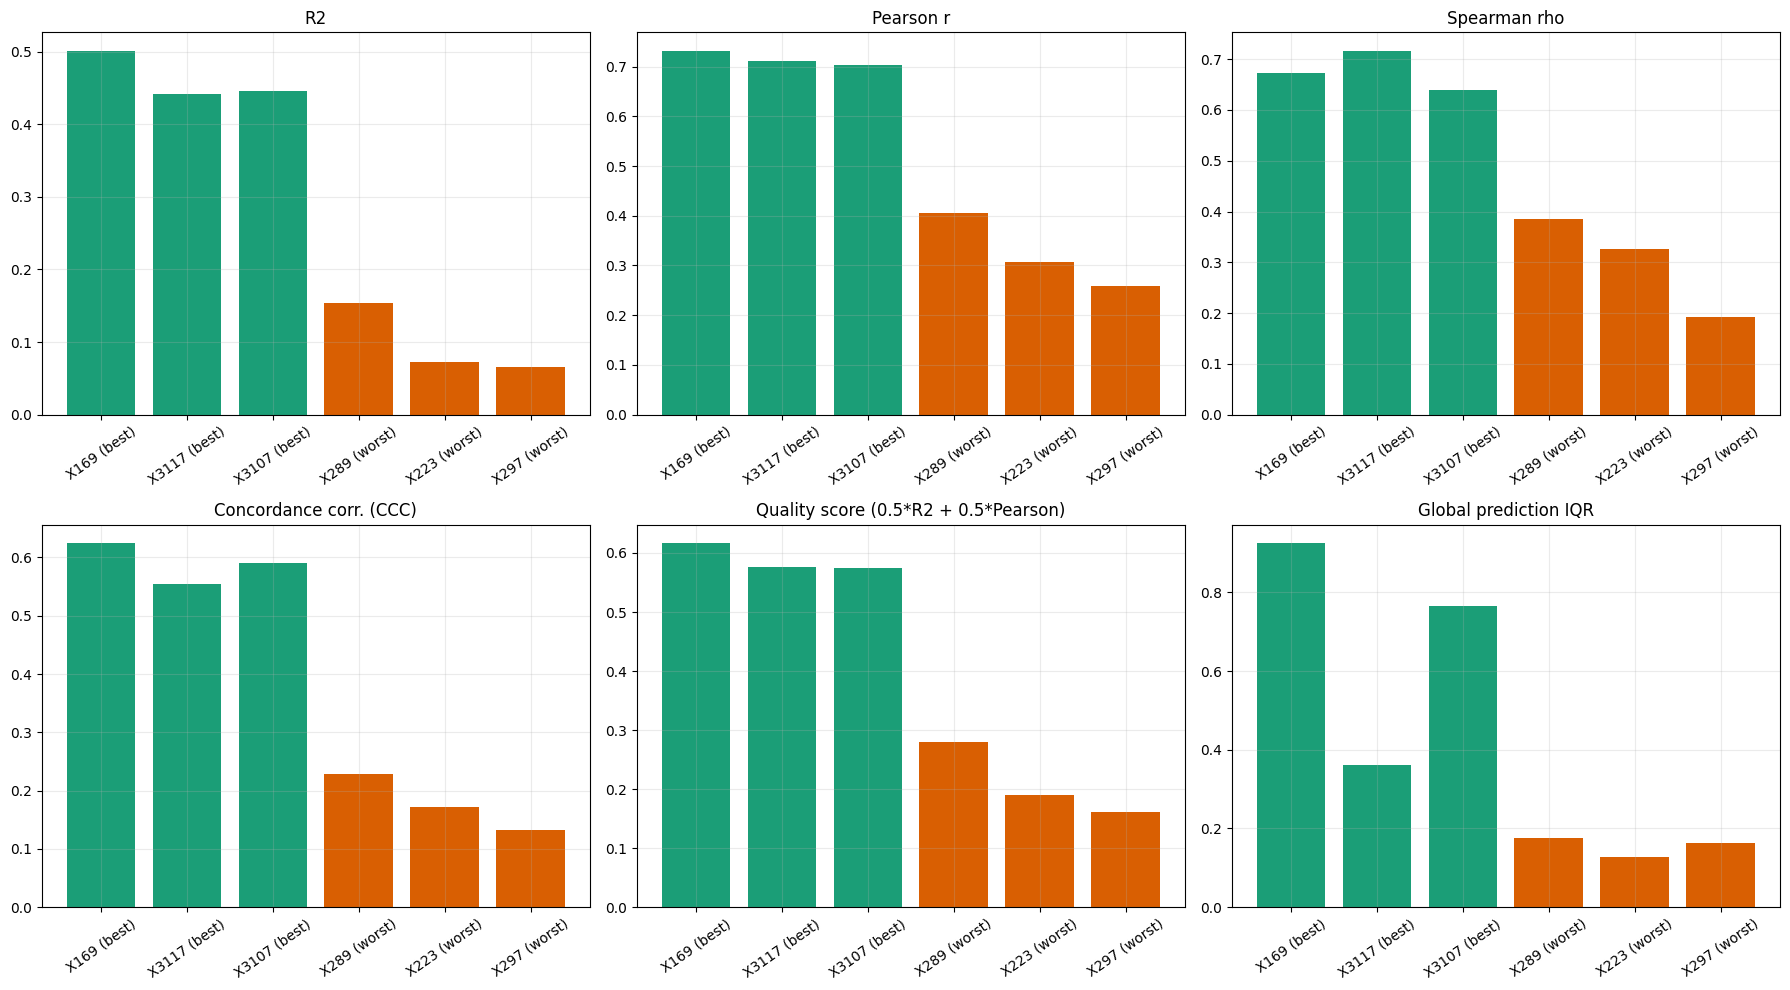

Saved bar charts: /scratch3/plant-traits-v2/ldominiak/plant-traits-earth-v2/notebooks/inference_outputs/best_worst_barcharts.png


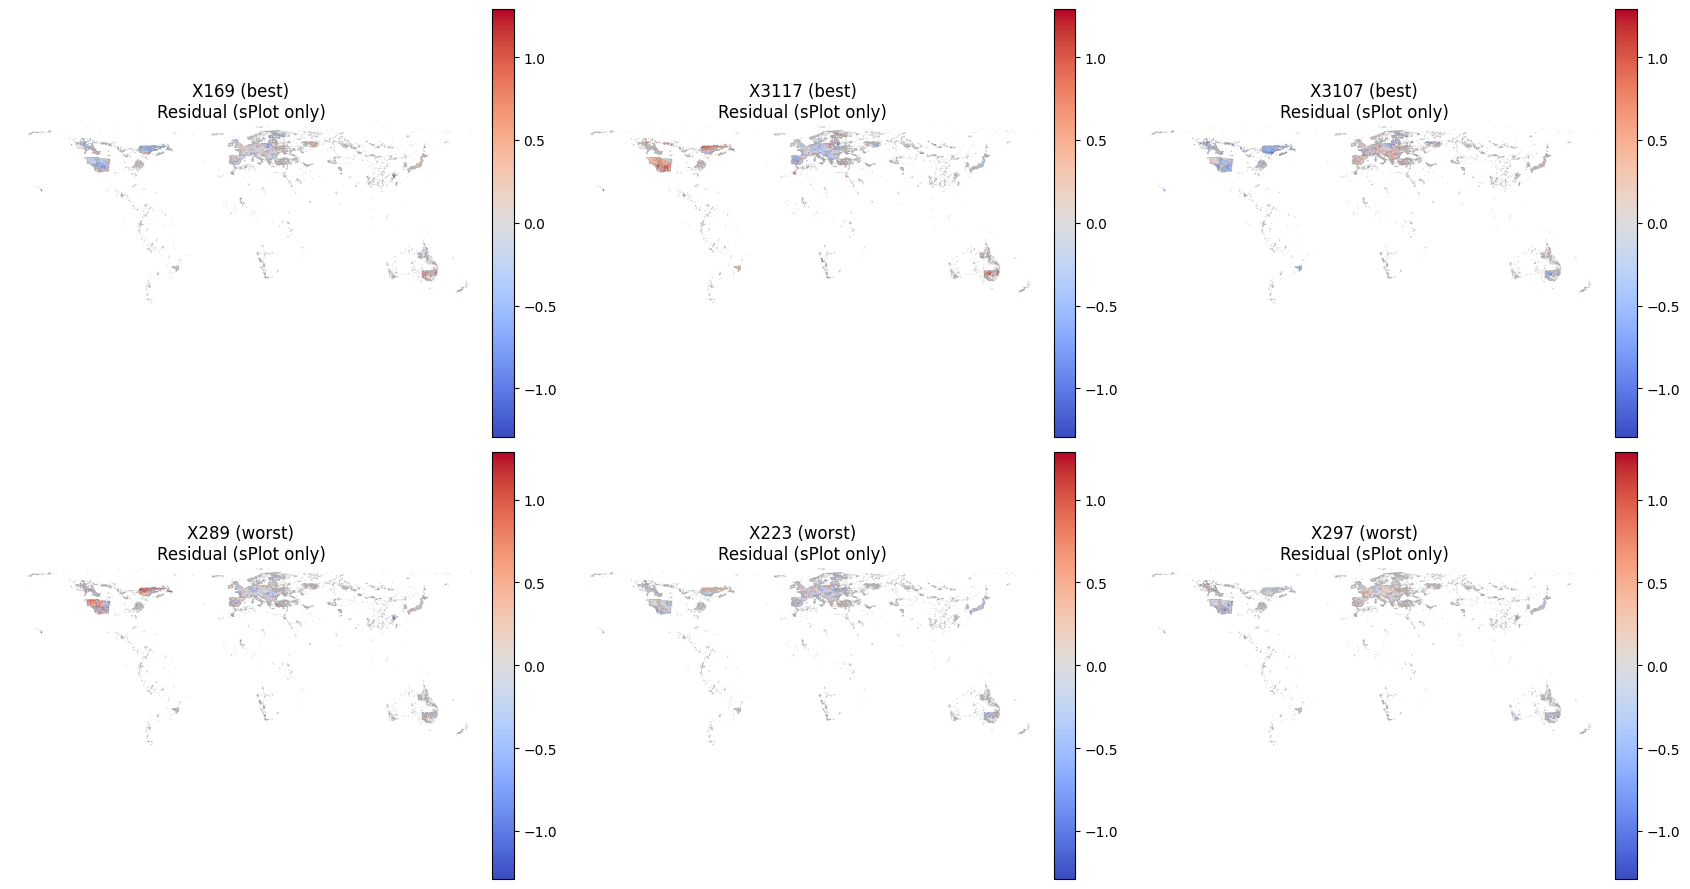

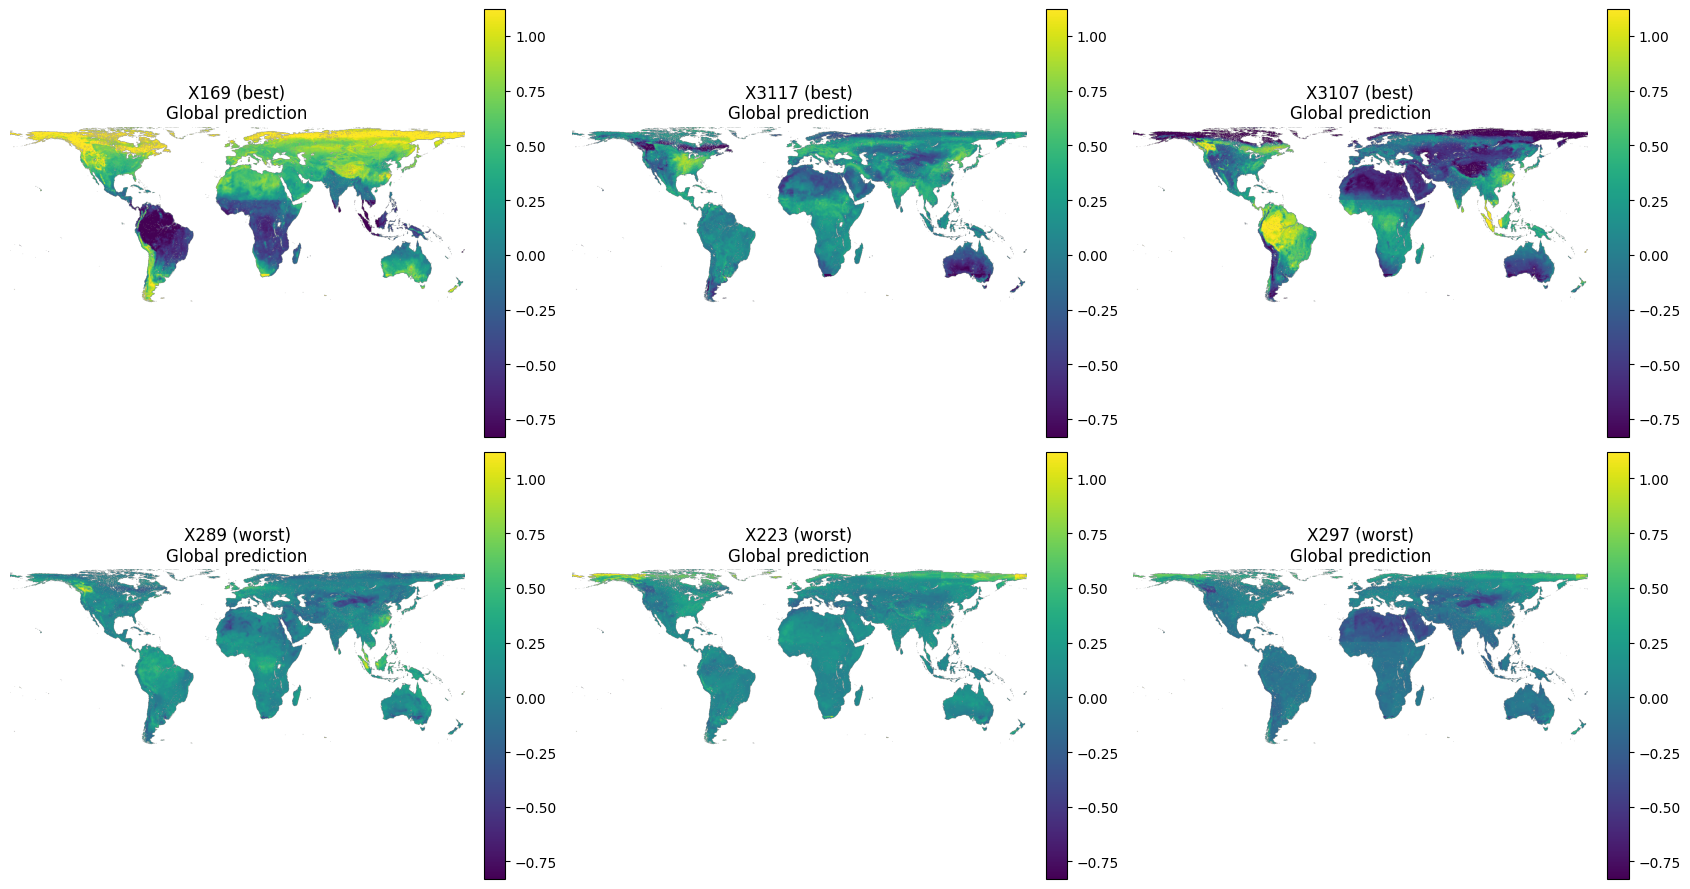

Saved residual map panel: /scratch3/plant-traits-v2/ldominiak/plant-traits-earth-v2/notebooks/inference_outputs/best_worst_residual_maps.png
Saved global prediction panel: /scratch3/plant-traits-v2/ldominiak/plant-traits-earth-v2/notebooks/inference_outputs/best_worst_global_prediction_maps.png


,group,trait_label,r2,pearson_r,spearman_r,ccc,quality_score,global_pred_mean,global_pred_iqr,n
0,best,X169,0.501450,0.732214,0.672593,0.624723,0.616832,0.358205,0.925460,23748
1,best,X3117,0.441692,0.710733,0.716965,0.555250,0.576212,0.059301,0.362534,23885
2,best,X3107,0.445383,0.703159,0.638939,0.590483,0.574271,-0.112799,0.766341,23996
3,worst,X289,0.153417,0.405748,0.385827,0.229072,0.279582,0.092335,0.176780,23736
4,worst,X223,0.072909,0.306612,0.325400,0.172484,0.189761,0.142969,0.127296,23854
5,worst,X297,0.066179,0.257853,0.193060,0.131713,0.162016,-0.038163,0.163246,23787


In [51]:
# Better comparison plots focused on R2 and correlation-style metrics (no RMSE/MAE/Bias bars).
if metrics_df.empty:
    raise RuntimeError("metrics_df is empty. Run metrics cell first.")

# Composite quality score using only R2 and Pearson r.
rank_df = metrics_df.copy()
rank_df["quality_score"] = 0.5 * rank_df["r2"].astype(float) + 0.5 * rank_df[
    "pearson_r"
].astype(float)

best3 = rank_df.nlargest(3, "quality_score").copy()
worst3 = rank_df.nsmallest(3, "quality_score").copy()
best3["group"] = "best"
worst3["group"] = "worst"
focus_df = pd.concat([best3, worst3], ignore_index=True)


def _spearman_r(x: np.ndarray, y: np.ndarray) -> float:
    rx = pd.Series(x).rank(method="average").to_numpy(dtype=np.float64)
    ry = pd.Series(y).rank(method="average").to_numpy(dtype=np.float64)
    if rx.size < 2:
        return float("nan")
    return float(np.corrcoef(rx, ry)[0, 1])


def _ccc(x: np.ndarray, y: np.ndarray) -> float:
    x = x.astype(np.float64, copy=False)
    y = y.astype(np.float64, copy=False)
    if x.size < 2:
        return float("nan")
    mx, my = float(np.mean(x)), float(np.mean(y))
    vx, vy = float(np.var(x)), float(np.var(y))
    cov = float(np.mean((x - mx) * (y - my)))
    denom = vx + vy + (mx - my) ** 2
    if denom <= 0.0:
        return float("nan")
    return float((2.0 * cov) / denom)


extra_rows = []
residual_maps = {}
prediction_maps = {}

with rasterio.open(PRED_TIF) as pred_src, rasterio.open(SOURCE_TIF) as src_ref:
    source_band = src_ref.read(src_ref.count).astype(np.float32)
    splot_mask = np.isfinite(source_band) & np.isclose(
        source_band, SPLOT_MASK_VALUE, atol=0.25
    )

    for _, row in focus_df.iterrows():
        trait_label = str(row["trait_label"])
        trait_id = int(row["trait_id"])
        band_idx = int(row["band_index"])

        tgt_match = match_df.loc[match_df["trait_label"] == trait_label, "target_path"]
        if tgt_match.empty:
            raise ValueError(f"No target file found for trait {trait_label}.")
        target_path = Path(str(tgt_match.iloc[0]))

        with rasterio.open(target_path) as tgt_src:
            y_true_full = tgt_src.read(1).astype(np.float32)
        y_pred_full = pred_src.read(band_idx).astype(np.float32)

        valid = splot_mask & np.isfinite(y_true_full) & np.isfinite(y_pred_full)
        if int(valid.sum()) < MIN_VALID_PIXELS:
            raise RuntimeError(
                f"Trait {trait_label} has too few valid sPlot pixels for robust stats."
            )

        y_true = y_true_full[valid]
        y_pred = y_pred_full[valid]

        spearman_r = _spearman_r(y_true, y_pred)
        ccc = _ccc(y_true, y_pred)

        global_valid = np.isfinite(y_pred_full)
        if int(global_valid.sum()) == 0:
            global_mean = float("nan")
            global_iqr = float("nan")
        else:
            gv = y_pred_full[global_valid].astype(np.float64)
            global_mean = float(np.mean(gv))
            q75 = float(np.quantile(gv, 0.75))
            q25 = float(np.quantile(gv, 0.25))
            global_iqr = q75 - q25

        residual = np.full(y_true_full.shape, np.nan, dtype=np.float32)
        residual[valid] = y_pred.astype(np.float32) - y_true.astype(np.float32)

        residual_maps[trait_label] = residual
        prediction_maps[trait_label] = y_pred_full

        extra_rows.append(
            {
                "trait_label": trait_label,
                "trait_id": trait_id,
                "band_index": band_idx,
                "group": row["group"],
                "n": int(valid.sum()),
                "r2": float(row["r2"]),
                "pearson_r": float(row["pearson_r"]),
                "quality_score": float(row["quality_score"]),
                "spearman_r": float(spearman_r),
                "ccc": float(ccc),
                "global_pred_mean": float(global_mean),
                "global_pred_iqr": float(global_iqr),
            }
        )

focus_df = pd.DataFrame(extra_rows)
focus_df = focus_df.sort_values(
    ["group", "quality_score"], ascending=[True, False]
).reset_index(drop=True)

focus_csv = OUT_DIR / "best_worst_traits_summary.csv"
focus_df.to_csv(focus_csv, index=False)
print("Saved focus trait summary:", focus_csv)

# Bar charts: only R2 / Pearson and correlation-style extra metrics.
plot_df = focus_df.copy()
plot_df["label"] = plot_df["trait_label"] + " (" + plot_df["group"] + ")"

bar_png = OUT_DIR / "best_worst_barcharts.png"
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = [
    ("r2", "R2"),
    ("pearson_r", "Pearson r"),
    ("spearman_r", "Spearman rho"),
    ("ccc", "Concordance corr. (CCC)"),
    ("quality_score", "Quality score (0.5*R2 + 0.5*Pearson)"),
    ("global_pred_iqr", "Global prediction IQR"),
]

for ax, (col, title) in zip(axes.flatten(), metrics_to_plot):
    vals = plot_df[col].to_numpy(dtype=np.float64)
    colors = ["#1b9e77" if g == "best" else "#d95f02" for g in plot_df["group"]]
    ax.bar(plot_df["label"], vals, color=colors)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(bar_png, dpi=190, bbox_inches="tight")
plt.show()
print("Saved bar charts:", bar_png)

# Map panels with shared scales for comparability.
resid_map_png = OUT_DIR / "best_worst_residual_maps.png"
pred_map_png = OUT_DIR / "best_worst_global_prediction_maps.png"

all_abs_res = []
for arr in residual_maps.values():
    vals = np.abs(arr[np.isfinite(arr)])
    if vals.size > 0:
        all_abs_res.append(vals)
if len(all_abs_res) == 0:
    resid_vmax = 1.0
else:
    resid_vmax = float(np.quantile(np.concatenate(all_abs_res), 0.97))
    if not np.isfinite(resid_vmax) or resid_vmax <= 0:
        resid_vmax = 1.0

all_pred_vals = []
for arr in prediction_maps.values():
    vals = arr[np.isfinite(arr)]
    if vals.size > 0:
        all_pred_vals.append(vals.astype(np.float64))
if len(all_pred_vals) == 0:
    pred_vmin, pred_vmax = 0.0, 1.0
else:
    concat_pred = np.concatenate(all_pred_vals)
    pred_vmin = float(np.quantile(concat_pred, 0.02))
    pred_vmax = float(np.quantile(concat_pred, 0.98))
    if not np.isfinite(pred_vmin):
        pred_vmin = 0.0
    if not np.isfinite(pred_vmax) or pred_vmax <= pred_vmin:
        pred_vmax = pred_vmin + 1.0

n = plot_df.shape[0]
fig_r, axes_r = plt.subplots(2, 3, figsize=(17, 9))
fig_p, axes_p = plt.subplots(2, 3, figsize=(17, 9))

for ax in axes_r.flatten()[n:]:
    ax.axis("off")
for ax in axes_p.flatten()[n:]:
    ax.axis("off")

for i, (_, row) in enumerate(plot_df.iterrows()):
    trait_label = str(row["trait_label"])

    res = residual_maps[trait_label]
    pred = prediction_maps[trait_label]

    axr = axes_r.flatten()[i]
    imr = axr.imshow(res, cmap="coolwarm", vmin=-resid_vmax, vmax=resid_vmax)
    axr.set_title(f"{trait_label} ({row['group']})\nResidual (sPlot only)")
    axr.axis("off")
    fig_r.colorbar(imr, ax=axr, fraction=0.046, pad=0.04)

    axp = axes_p.flatten()[i]
    imp = axp.imshow(pred, cmap="viridis", vmin=pred_vmin, vmax=pred_vmax)
    axp.set_title(f"{trait_label} ({row['group']})\nGlobal prediction")
    axp.axis("off")
    fig_p.colorbar(imp, ax=axp, fraction=0.046, pad=0.04)

fig_r.tight_layout()
fig_p.tight_layout()
fig_r.savefig(resid_map_png, dpi=190, bbox_inches="tight")
fig_p.savefig(pred_map_png, dpi=190, bbox_inches="tight")
plt.show()

print("Saved residual map panel:", resid_map_png)
print("Saved global prediction panel:", pred_map_png)

display(
    focus_df[
        [
            "group",
            "trait_label",
            "r2",
            "pearson_r",
            "spearman_r",
            "ccc",
            "quality_score",
            "global_pred_mean",
            "global_pred_iqr",
            "n",
        ]
    ]
)

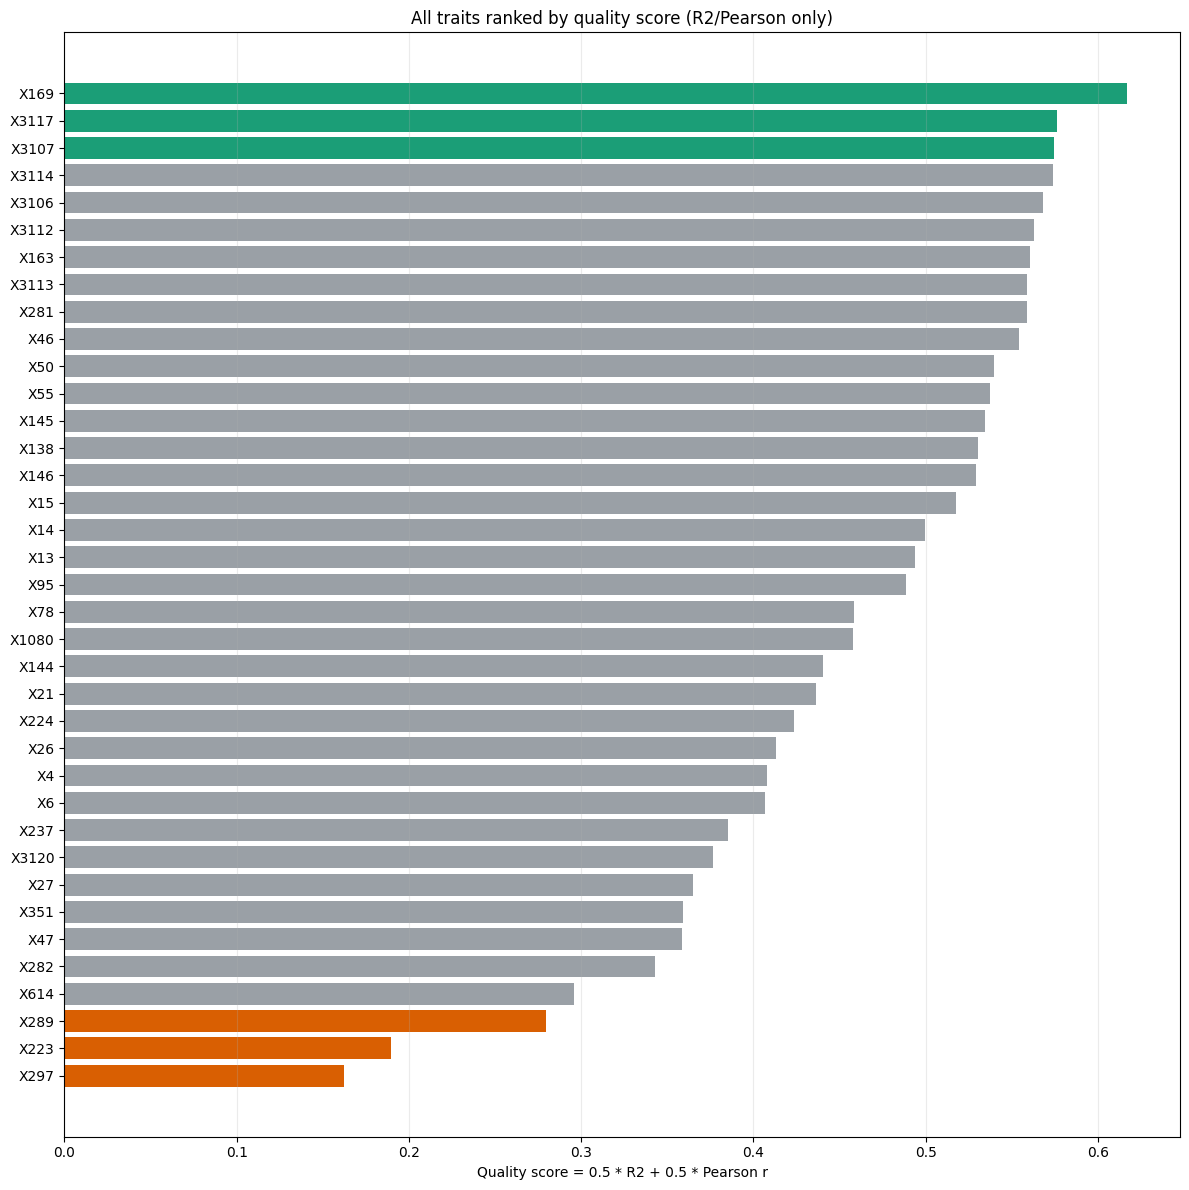

Saved quality ranking plot: /scratch3/plant-traits-v2/ldominiak/plant-traits-earth-v2/notebooks/inference_outputs/all_traits_quality_ranking.png


,trait_label,r2,pearson_r,quality_score,n
0,X169,0.501450,0.732214,0.616832,23748
1,X3117,0.441692,0.710733,0.576212,23885
2,X3107,0.445383,0.703159,0.574271,23996
3,X3114,0.461986,0.685861,0.573924,23927
4,X3106,0.438970,0.697011,0.567991,23968
5,X3112,0.449497,0.676228,0.562862,23902
6,X163,0.448659,0.672736,0.560697,23910
7,X3113,0.442639,0.675587,0.559113,23878
8,X281,0.440844,0.676853,0.558849,23819
9,X46,0.430118,0.678247,0.554182,23921


,trait_label,r2,pearson_r,quality_score,n
27,X237,0.253175,0.516908,0.385042,23836
28,X3120,0.218357,0.534336,0.376347,23927
29,X27,0.237733,0.491587,0.364660,23966
30,X351,0.227618,0.490716,0.359167,23765
31,X47,0.208485,0.508960,0.358723,23960
32,X282,0.214529,0.471547,0.343038,23796
33,X614,0.171547,0.419870,0.295708,23859
34,X289,0.153417,0.405748,0.279582,23736
35,X223,0.072909,0.306612,0.189761,23854
36,X297,0.066179,0.257853,0.162016,23787


In [52]:
# Global view: all traits ranked by quality score built from R2 and Pearson r.
all_rank_df = metrics_df.copy()
all_rank_df["quality_score"] = 0.5 * all_rank_df["r2"].astype(
    float
) + 0.5 * all_rank_df["pearson_r"].astype(float)
all_rank_df = all_rank_df.sort_values("quality_score", ascending=False).reset_index(
    drop=True
)

rank_png = OUT_DIR / "all_traits_quality_ranking.png"
fig, ax = plt.subplots(figsize=(12, 12))

labels = all_rank_df["trait_label"].tolist()
values = all_rank_df["quality_score"].to_numpy(dtype=np.float64)

highlight = set(focus_df["trait_label"].tolist()) if "focus_df" in globals() else set()
colors = []
for trait in labels:
    if trait in highlight:
        group = focus_df.loc[focus_df["trait_label"] == trait, "group"].iloc[0]
        colors.append("#1b9e77" if group == "best" else "#d95f02")
    else:
        colors.append("#9aa0a6")

ax.barh(labels[::-1], values[::-1], color=colors[::-1])
ax.set_title("All traits ranked by quality score (R2/Pearson only)")
ax.set_xlabel("Quality score = 0.5 * R2 + 0.5 * Pearson r")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(rank_png, dpi=190, bbox_inches="tight")
plt.show()
print("Saved quality ranking plot:", rank_png)

display(all_rank_df[["trait_label", "r2", "pearson_r", "quality_score", "n"]].head(10))
display(all_rank_df[["trait_label", "r2", "pearson_r", "quality_score", "n"]].tail(10))

## Best and Worst Traits (Top-3 / Bottom-3)

Diese Sektion zeigt fuer die 3 besten und 3 schlechtesten Traits (nach RMSE):
- Metriken
- Residualkarten (nur sPlot-Pixel)
- globale Vorhersagekarten
- Balkendiagramme fuer RMSE, MAE, Bias, R2 und globalen Vorhersage-Mittelwert

### Exporte

- `trait_metrics_splot_pixels.csv`: Kennzahlen pro Trait auf sPlot-Pixeln.
- `metrics_summary.json`: Aggregierte Kennzahlen ueber alle ausgewerteten Traits.
- `residual_maps_png/*.png`: Residual-Karten pro Trait (nur sPlot-Pixel, sonst NaN).
- `residual_maps_splot_only.tif`: Multi-Band-Stack der Residual-Karten in Trait-Reihenfolge.
- `residual_pattern_summary.csv`: Bias und RMSE je Trait fuer den Residual-Vergleich.